# 03 Model Building & Training

TF-IDF feeds six classic ML classifiers. We compare them, tune the best, and show a prediction. all numbers are produced by running the code.

## 1. Importing libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import Utility
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
import warnings
warnings.filterwarnings("ignore")

## 2. Upload dataset

In [53]:
df = pd.read_csv('resume_cleaned.csv').dropna(subset=['clean_text', 'label'])
print('rows:', len(df), '| classes:', df['label'].nunique())

rows: 962 | classes: 25


## 3. TF-IDF features + train/test split

In [54]:
# Keep raw text split SEPARATE so we can use it for prediction later
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
X_train = vectorizer.fit_transform(X_train_raw)
X_test  = vectorizer.transform(X_test_raw)
print('TF-IDF:', X_train.shape)

TF-IDF: (769, 20000)


## 4. Comparing the models

In [55]:
results = []
for name, model in Utility.get_models().items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append(Utility.evaluate_models(name, y_test, pred))

res_df = Utility.compare_models(results)
res_df.round(4)


,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,1.0000,1.0000,1.0000,1.0000
1,Passive Aggressive,1.0000,1.0000,1.0000,1.0000
2,Ridge Classifier,0.9948,0.9957,0.9948,0.9949
3,Complement NB,0.9948,0.9956,0.9948,0.9947
4,Logistic Regression,0.9896,0.9907,0.9896,0.9895
5,Multinomial NB,0.9793,0.9817,0.9793,0.9762


## 5. Comparision Chart

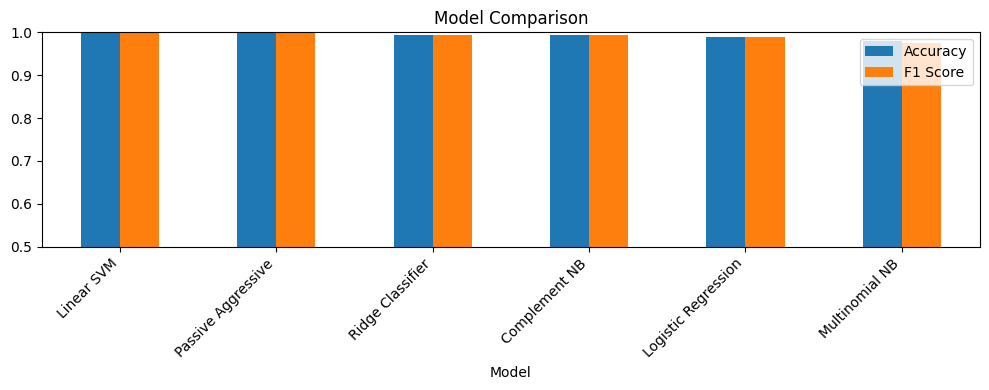

In [56]:
fig, ax = plt.subplots(figsize=(10, 4))
res_df.set_index('Model')[['Accuracy', 'F1 Score']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison')
ax.set_ylim(min(0.5, res_df['F1 Score'].min() - 0.05), 1.0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Confusion Matrix

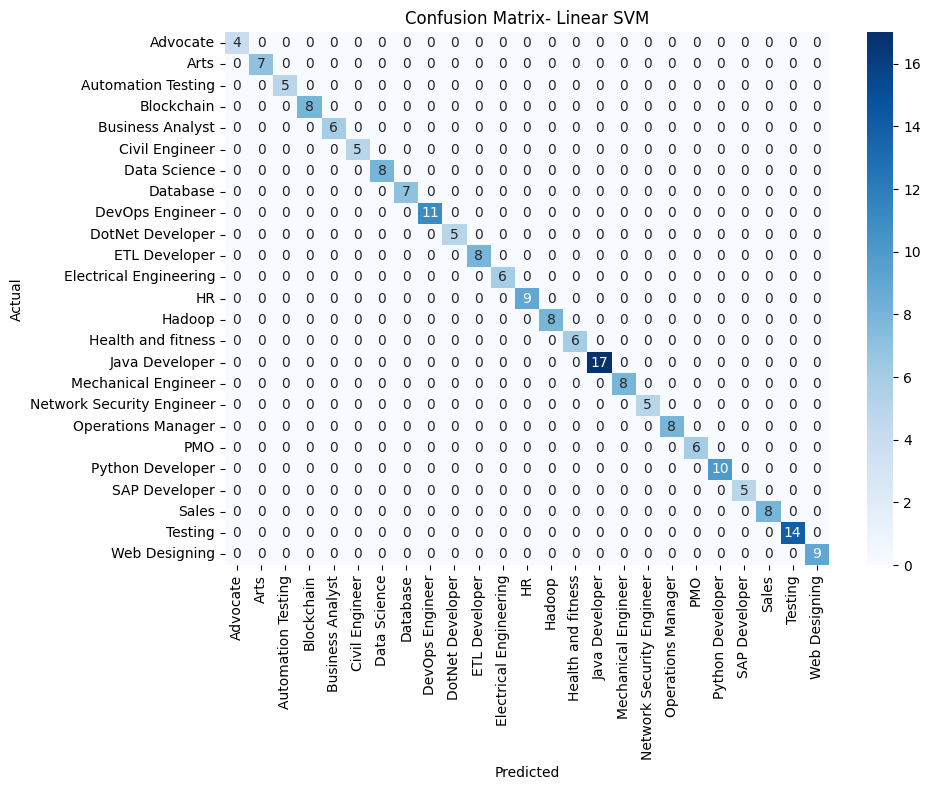

In [57]:
best_name = res_df.iloc[0]['Model']
best = Utility.get_models()[best_name]
best.fit(X_train, y_train)
pred = best.predict(X_test)

fig, ax = plt.subplots(figsize=(10, 8))
Utility.plot_confusion_matrix(y_test, pred, best_name, labels=sorted(df['label'].unique()), ax=ax)
plt.tight_layout()
plt.show()


## 7. Tune Linear SVM

In [58]:
from sklearn.svm import LinearSVC


gs = GridSearchCV(
    LinearSVC(max_iter=2000),
    {'C': [0.01, 0.1, 1, 10]},
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)
gs.fit(X_train, y_train)

tuned_pred = gs.best_estimator_.predict(X_test)
print('best C         :', gs.best_params_['C'])
print('tuned accuracy : %.4f' % accuracy_score(y_test, tuned_pred))
print('tuned F1       : %.4f' % f1_score(y_test, tuned_pred, average='weighted'))

best C         : 10
tuned accuracy : 1.0000
tuned F1       : 1.0000


## 8. Prediction Example

In [59]:
sample = X_test_raw.iloc[0]
print('text :', str(sample)[:160])
print('true :', y_test.iloc[0])
print('pred :', gs.best_estimator_.predict(vectorizer.transform([sample]))[0])

text : education details january bachelor engineering extc mumbai maharashtra mumbai university january diploma industrial electronics vashi maharashtra fr agnel polyt
true : ETL Developer
pred : ETL Developer


## 9. Summary

TF-IDF + a linear classifier is a strong, fast baseline for text classification; the best model and tuned Linear SVM scores are reported in the project README.